# KKBox — Phase 3: 6-Stage Revenue Funnel
Sequential CTEs enforce strict funnel logic: a user **must pass every prior stage** to enter the next.

In [4]:
import pandas as pd
import psycopg2
from IPython.display import display

DB = {
    "host":     "localhost",
    "port":     5432,
    "dbname":   "kkbox",
    "user":     "postgres",
    "password": "password",
}

def get_conn():
    return psycopg2.connect(**DB)

In [5]:
FUNNEL_SQL = """
WITH

/* ────────────────────────────────────────────────
   STAGE 1 — All registered users in members table
   ──────────────────────────────────────────────── */
s1_registered AS (
    SELECT DISTINCT user_id
    FROM   members
),

/* ────────────────────────────────────────────────
   STAGE 2 — Made at least one payment (amount_paid > 0)
   ──────────────────────────────────────────────── */
s2_first_payment AS (
    SELECT DISTINCT t.user_id
    FROM   transactions  t
    JOIN   s1_registered s1 ON s1.user_id = t.user_id
    WHERE  t.amount_paid > 0
),

/* ────────────────────────────────────────────────
   STAGE 3 — Did NOT cancel before their first expire_date
   Logic: exclude users who have ANY is_cancel=1 row whose
   transaction_date falls strictly before MIN(expire_date)
   ──────────────────────────────────────────────── */
s3_survived_first_period AS (
    SELECT s2.user_id
    FROM   s2_first_payment s2
    WHERE  NOT EXISTS (
        SELECT 1
        FROM   transactions t_cancel
        WHERE  t_cancel.user_id          = s2.user_id
          AND  t_cancel.is_cancel        = 1
          AND  t_cancel.transaction_date < (
               SELECT MIN(t_exp.expire_date)
               FROM   transactions t_exp
               WHERE  t_exp.user_id = s2.user_id
          )
    )
),

/* ────────────────────────────────────────────────
   STAGE 4 — Renewed at least twice
   (>= 2 paid, non-cancelled transactions)
   ──────────────────────────────────────────────── */
s4_renewed_twice AS (
    SELECT t.user_id
    FROM   transactions          t
    JOIN   s3_survived_first_period s3 ON s3.user_id = t.user_id
    WHERE  t.amount_paid > 0
      AND  t.is_cancel   = 0
    GROUP  BY t.user_id
    HAVING COUNT(*) >= 2
),

/* ────────────────────────────────────────────────
   STAGE 5 — Six-month tenure
   MAX(transaction_date) - MIN(transaction_date) >= 180 days
   (DATE - DATE in PostgreSQL returns an INTEGER of days)
   ──────────────────────────────────────────────── */
s5_six_month_tenure AS (
    SELECT t.user_id
    FROM   transactions     t
    JOIN   s4_renewed_twice s4 ON s4.user_id = t.user_id
    GROUP  BY t.user_id
    HAVING MAX(t.transaction_date) - MIN(t.transaction_date) >= 180
),

/* ────────────────────────────────────────────────
   STAGE 6 — Highly engaged
   engagement_score > global median (PERCENTILE_CONT 0.5)
   ──────────────────────────────────────────────── */
global_median AS (
    SELECT PERCENTILE_CONT(0.5)
               WITHIN GROUP (ORDER BY engagement_score) AS median_score
    FROM   user_engagement
),

s6_highly_engaged AS (
    SELECT e.user_id
    FROM   user_engagement       e
    JOIN   s5_six_month_tenure   s5 ON s5.user_id = e.user_id
    CROSS  JOIN global_median    gm
    WHERE  e.engagement_score > gm.median_score
),

/* ────────────────────────────────────────────────
   RAW COUNTS — materialise all 6 stage counts in one row
   ──────────────────────────────────────────────── */
counts AS (
    SELECT
        (SELECT COUNT(*) FROM s1_registered)            AS c1,
        (SELECT COUNT(*) FROM s2_first_payment)         AS c2,
        (SELECT COUNT(*) FROM s3_survived_first_period) AS c3,
        (SELECT COUNT(*) FROM s4_renewed_twice)         AS c4,
        (SELECT COUNT(*) FROM s5_six_month_tenure)      AS c5,
        (SELECT COUNT(*) FROM s6_highly_engaged)        AS c6
),

/* ────────────────────────────────────────────────
   UNPIVOT — one row per stage, preserve order for window fns
   ──────────────────────────────────────────────── */
stages AS (
    SELECT 1 AS stage_num, '1 - Registered'         AS stage_name, c1 AS user_count FROM counts
    UNION ALL
    SELECT 2,              '2 - First Payment',                     c2             FROM counts
    UNION ALL
    SELECT 3,              '3 - Survived 1st Period',               c3             FROM counts
    UNION ALL
    SELECT 4,              '4 - Renewed ≥2x',                       c4             FROM counts
    UNION ALL
    SELECT 5,              '5 - Six-Month Tenure',                  c5             FROM counts
    UNION ALL
    SELECT 6,              '6 - Highly Engaged',                    c6             FROM counts
),

/* ────────────────────────────────────────────────
   FUNNEL SUMMARY — conversions, drop-off, overall %
   ──────────────────────────────────────────────── */
funnel_summary AS (
    SELECT
        stage_num,
        stage_name                                                           AS "Stage_Name",
        user_count                                                           AS "User_Count",

        ROUND(
            user_count::NUMERIC
            / NULLIF(LAG(user_count) OVER (ORDER BY stage_num), 0)
            * 100, 2
        )                                                                    AS "Stage_Conversion_Pct",

        ROUND(
            user_count::NUMERIC
            / NULLIF(FIRST_VALUE(user_count) OVER (ORDER BY stage_num), 0)
            * 100, 2
        )                                                                    AS "Overall_Conversion_Pct",

        COALESCE(
            LAG(user_count) OVER (ORDER BY stage_num) - user_count, 0
        )                                                                    AS "Absolute_Dropoff_Volume"

    FROM stages
)

SELECT
    "Stage_Name",
    "User_Count",
    "Stage_Conversion_Pct",
    "Overall_Conversion_Pct",
    "Absolute_Dropoff_Volume"
FROM funnel_summary
ORDER BY stage_num;
"""

conn = get_conn()
df_funnel = pd.read_sql(FUNNEL_SQL, conn)
conn.close()

# ── Display ──────────────────────────────────────────────────────────────────
pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_colwidth", None)

df_funnel["User_Count"]              = df_funnel["User_Count"].map("{:,}".format)
df_funnel["Absolute_Dropoff_Volume"] = df_funnel["Absolute_Dropoff_Volume"].map("{:,}".format)
df_funnel["Stage_Conversion_Pct"]    = df_funnel["Stage_Conversion_Pct"].apply(
    lambda x: "—" if pd.isna(x) else f"{x:.2f}%"
)
df_funnel["Overall_Conversion_Pct"]  = df_funnel["Overall_Conversion_Pct"].apply(
    lambda x: f"{x:.2f}%"
)

print(df_funnel.to_markdown(index=False, tablefmt="github"))

C:\Users\Vamsi Bhogaraju\AppData\Local\Temp\ipykernel_80296\1483576148.py:157: UserWarning:

pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.



| Stage_Name              | User_Count   | Stage_Conversion_Pct   | Overall_Conversion_Pct   | Absolute_Dropoff_Volume   |
|-------------------------|--------------|------------------------|--------------------------|---------------------------|
| 1 - Registered          | 6,769,472    | —                      | 100.00%                  | 0                         |
| 2 - First Payment       | 1,074,938    | 15.88%                 | 15.88%                   | 5,694,534                 |
| 3 - Survived 1st Period | 1,063,557    | 98.94%                 | 15.71%                   | 11,381                    |
| 4 - Renewed ≥2x         | 108,447      | 10.20%                 | 1.60%                    | 955,110                   |
| 5 - Six-Month Tenure    | 6,645        | 6.13%                  | 0.10%                    | 101,802                   |
| 6 - Highly Engaged      | 3,303        | 49.71%                 | 0.05%                    | 3,342                     |


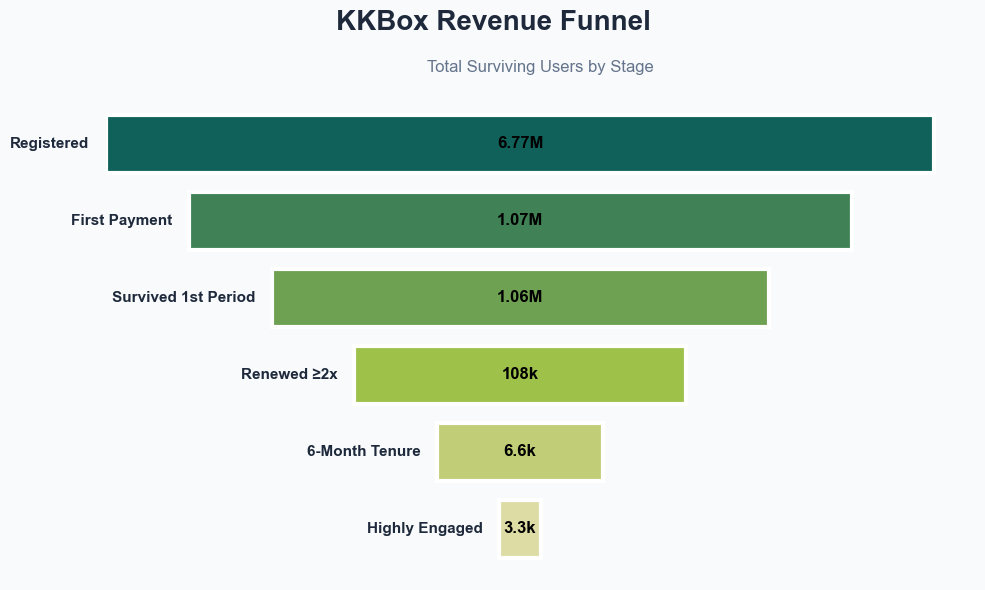

Matplotlib Funnel saved → ./Data/outputs/revenue_funnel_sns.png


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

os.makedirs("./Data/outputs", exist_ok=True)

# 1. The Data
stages = ["Registered", "First Payment", "Survived 1st Period", "Renewed ≥2x", "6-Month Tenure", "Highly Engaged"]
formatted_texts = ["6.77M", "1.07M", "1.06M", "108k", "6.6k", "3.3k"]

# To prevent the bottom from crushing into an invisible line, we use cleanly 
# decreasing geometry widths (just like we did with the Plotly trick).
visual_widths = [100, 80, 60, 40, 20, 5]

# 2. Set up the exact visual aesthetic
sns.set_theme(style="white", rc={"axes.facecolor": "#f8fafc", "figure.facecolor": "#f8fafc"})
fig, ax = plt.subplots(figsize=(10, 6))

# Since Matplotlib just draws bars left-to-right, we calculate the "left" 
# X-coordinate offset for each bar to force them to balance exactly in the middle.
max_width = visual_widths[0]
lefts = [(max_width - w) / 2 for w in visual_widths]


colors = ["#11615b", "#408156", "#6fa152", "#9ec14a", "#c1ce77", "#dedca5"]
y_pos = np.arange(len(stages))[::-1] # Build from top to bottom

# 3. Draw the Funnel (Centered Horizontal Bar Chart)
bars = ax.barh(
    y=y_pos, 
    width=visual_widths, 
    left=lefts, 
    color=colors, 
    height=0.75,       # Bar thickness
    edgecolor="white", # The modern white gaps between stages
    linewidth=3
)

# 4. Add the labels perfectly over the math
for idx, (bar, text_val) in enumerate(zip(bars, formatted_texts)):
    # Put the actual KKBox math directly in the middle of the shape
    ax.text(
        bar.get_x() + bar.get_width() / 2, 
        bar.get_y() + bar.get_height() / 2, 
        text_val,
        ha='center', va='center', color='black', # 👇 CHANGE TO BLACK HERE 👇
        fontweight='bold', fontsize=12
    )

    
    # Hug the stage name cleanly to the left edge of the shape
    ax.text(
        lefts[idx] - 2, # 2 points padding to the left of the shape
        bar.get_y() + bar.get_height() / 2, 
        stages[idx], 
        ha='right', va='center', color='#1e293b', 
        fontweight='bold', fontsize=11
    )

# 5. Clean off everything else completely
ax.axis("off") 

plt.suptitle("KKBox Revenue Funnel", y=0.98, fontsize=20, fontweight="bold", color="#1e293b", family="sans-serif")
plt.title("Total Surviving Users by Stage", fontsize=12, color="#64748b", pad=15)

plt.tight_layout()
plt.savefig("./Data/outputs/revenue_funnel_sns.png", dpi=200, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()

print("Matplotlib Funnel saved → ./Data/outputs/revenue_funnel_sns.png")
